In [7]:
import constants as c
import numpy as np
import math
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.integrate import solve_ivp

vk = c.vk
vrf = c.vrf
z0 = c.z0
xy1k = c.xy1k
xy2k = c.xy2k
pi = math.pi
um = c.um
cm = c.cm
mm = c.mm
K = c.K
e = c.e
eps = 1
alpha = 1/137.06
m_dm = 2.873e-25
m_ion = c.m 
Z_charge = c.Z
freq_x = 719430.7131391969
freq_y = 3031200.0099101723
freq_z = 3002153.5607483205
omega = 2*pi*np.array([freq_x,freq_y,freq_z])

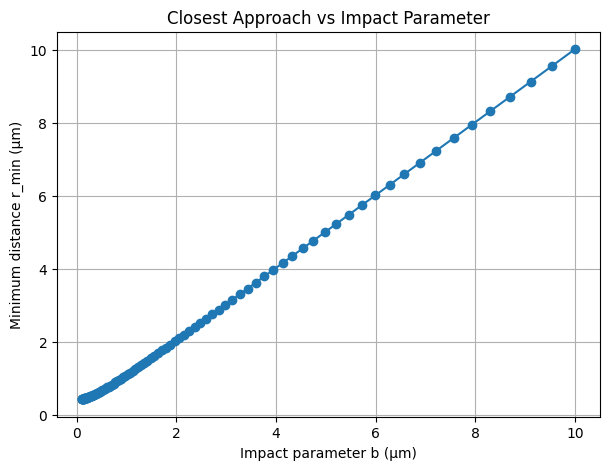

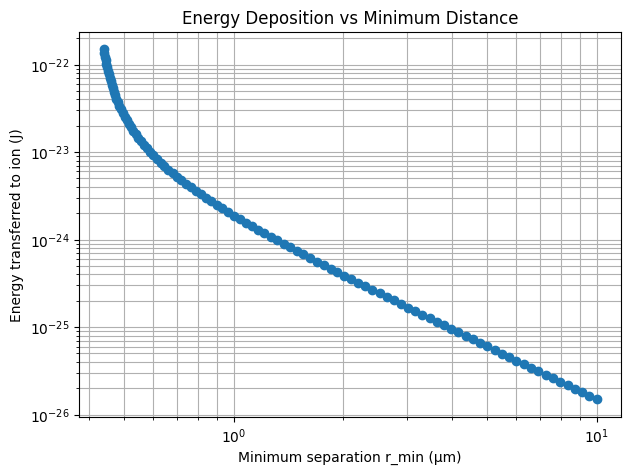

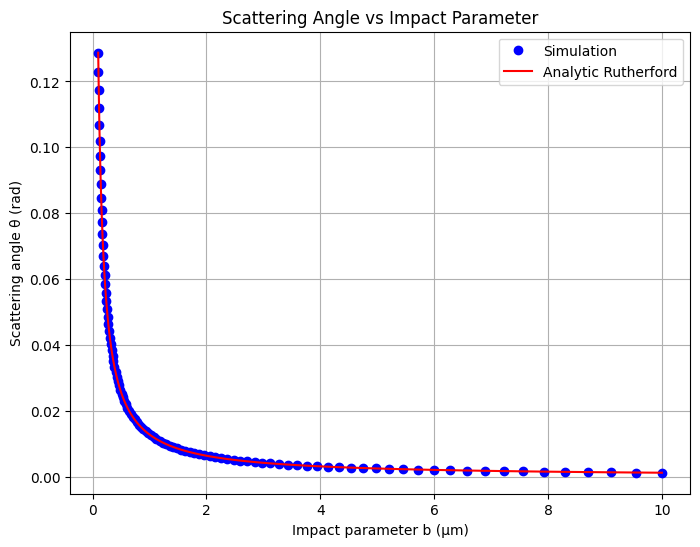

In [ ]:
## 3. Simulate Rutherford scattering without the potential; use an ODE package to solve a coupled system
# Initial condition- for ion: rest and equilibrium
x0_ion = [0,0,0] # initial position
v0_ion = [0,0,0] # initial velocity

# Random initial condition- for DM: r0=100um, v0=500m/s
r_trap = 1*cm
speed_dm = 500 
b_list = np.logspace(-5, -3, 100)  # 10 µm to 1 mm

# Solve coupled equations of motion
def fun2(t,U):
    x_ion = U[0:3]
    x_dm = U[3:6]
    v_ion = U[6:9]
    v_dm = U[9:12]
    E_trap = 0; # without trap potential 
    omega = 0; # without trap potential
    delta_r = x_ion - x_dm
    dx_iondt = v_ion
    dv_iondt = -omega**2*x_ion+K*eps*e**2*delta_r/(m_ion*np.linalg.norm(delta_r)**3)
    dx_dmdt = v_dm
    dv_dmdt = -eps*e*E_trap/m_dm-K*eps*e**2*delta_r/(m_dm*np.linalg.norm(delta_r)**3)
    return np.concatenate([dx_iondt,dx_dmdt,dv_iondt,dv_dmdt])

def scattering_angle_cm(sol):
    v1_ion, v2_ion, v3_ion = sol.y[6], sol.y[7], sol.y[8]
    v1_dm,  v2_dm,  v3_dm  = sol.y[9], sol.y[10], sol.y[11]

    v_rel0 = np.array([v1_dm[0] - v1_ion[0],
                       v2_dm[0] - v2_ion[0],
                       v3_dm[0] - v3_ion[0]])

    v_relF = np.array([v1_dm[-1] - v1_ion[-1],
                       v2_dm[-1] - v2_ion[-1],
                       v3_dm[-1] - v3_ion[-1]])

    cosθ = np.dot(v_relF, v_rel0) / (np.linalg.norm(v_relF)*np.linalg.norm(v_rel0))
    cosθ = np.clip(cosθ, -1, 1)
    return np.arccos(cosθ)

def min_distance(sol):
    x1_ion, x2_ion, x3_ion = sol.y[0], sol.y[1], sol.y[2]
    x1_dm,  x2_dm,  x3_dm  = sol.y[3], sol.y[4], sol.y[5]
    r = np.sqrt((x1_ion-x1_dm)**2 + (x2_ion-x2_dm)**2 + (x3_ion-x3_dm)**2)
    return np.min(r)

def energy_deposited_ion(sol):
    v1, v2, v3 = sol.y[6,-1], sol.y[7,-1], sol.y[8,-1]
    return 0.5 * m_ion * (v1**2 + v2**2 + v3**2)

# Run a single event
t_span = (0, 5e-3)
t_eval = np.linspace(0, 5e-3, 20000)

def run_one_event(r_trap, speed_dm, b):
    x0_dm = np.array([-r_trap, b, 0])
    v0_dm = np.array([speed_dm, 0, 0])

    U0 = np.concatenate([x0_ion, x0_dm, v0_ion, v0_dm])

    sol = solve_ivp(fun2, t_span, U0, method='DOP853',
                    t_eval=t_eval, rtol=1e-10, atol=1e-12)
    return sol

# Collect scattering, minimum distance, energy deposition
thetas = []
rmins  = []
Edeps  = []

for b in b_list:
    sol = run_one_event(r_trap, speed_dm, b)

    thetas.append(scattering_angle_cm(sol))
    rmins.append(min_distance(sol))
    Edeps.append(energy_deposited_ion(sol))

thetas = np.array(thetas)
rmins  = np.array(rmins)
Edeps  = np.array(Edeps)

# Plot 1: r_min(b)
plt.figure(figsize=(7,5))
plt.plot(b_list*1e6, rmins*1e6, 'o-')
plt.xlabel("Impact parameter b (µm)")
plt.ylabel("Minimum distance r_min (µm)")
plt.title("Closest Approach vs Impact Parameter")
plt.grid(True)
plt.show()

# Plot 2: ΔE_ion(r_min)
plt.figure(figsize=(7,5))
plt.loglog(rmins*1e6, Edeps, 'o')
plt.xlabel("Minimum separation r_min (µm)")
plt.ylabel("Energy transferred to ion (J)")
plt.title("Energy Deposition vs Minimum Distance")
plt.grid(True, which='both')
plt.show()

# Compare to analytical Rutherford
q1 = e
q2 = eps * e
mu = (m_dm * m_ion) / (m_dm + m_ion)
E  = 0.5 * mu * speed_dm**2
C  = K*q1*q2

b_nonzero = b_list.copy()
b_nonzero[b_nonzero == 0] = np.nan
thetas_analytic = 2*np.arctan(C/(2*E*b_nonzero))

plt.figure(figsize=(8,6))
plt.plot(b_list*1e6, thetas, 'bo', label="Simulation")
plt.plot(b_list*1e6, thetas_analytic, 'r-', label="Analytic Rutherford")
plt.xlabel("Impact parameter b (µm)")
plt.ylabel("Scattering angle θ (rad)")
plt.title("Scattering Angle vs Impact Parameter")
plt.legend()
plt.grid(True)
plt.show()